In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int
    equation: str
    discriminant: float
    result: str

In [3]:
def show_equation(state: QuadState):
    equation = f' ({state["a"]}) (x^2) + ({state["b"]}) (x) + ({state["c"]}) '
    return {'equation': equation}

In [4]:
def calculate_discriminant(state: QuadState):
    discriminant = state["b"] ** 2 - (4 * state["a"] * state["c"])
    return {'discriminant': discriminant}

In [5]:
def real_roots(state: QuadState):
    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])
    result = f'The roots are {root1} and {root2}'
    return {'result': result}

In [6]:
def repeated_roots(state: QuadState):
    root = (-state["b"])/(2*state["a"])
    result = f'Only repeating root is {root}'
    return {'result': result}

In [7]:
def no_real_roots(state: QuadState):
    result = f'No real roots'
    return {'result': result}

In [8]:
def check_conditions(state: QuadState) -> Literal["RealRoots", "RepeatedRoots", "NoRealRoots"]:
    if state['discriminant'] > 0:
        return "RealRoots"
    elif state['discriminant'] == 0:
        return "RepeatedRoots"
    else:
        return "NoRealRoots"

In [9]:
graph = StateGraph(QuadState)

graph.add_node('ShowEquation', show_equation)
graph.add_node('CalculateDiscriminant', calculate_discriminant)
graph.add_node('RealRoots', real_roots)
graph.add_node('RepeatedRoots', repeated_roots)
graph.add_node('NoRealRoots', no_real_roots)

graph.add_edge(START, 'ShowEquation')
graph.add_edge('ShowEquation', 'CalculateDiscriminant')
graph.add_conditional_edges('CalculateDiscriminant', check_conditions)
graph.add_edge('RealRoots', END)
graph.add_edge('RepeatedRoots', END)
graph.add_edge('NoRealRoots', END)

workflow = graph.compile()

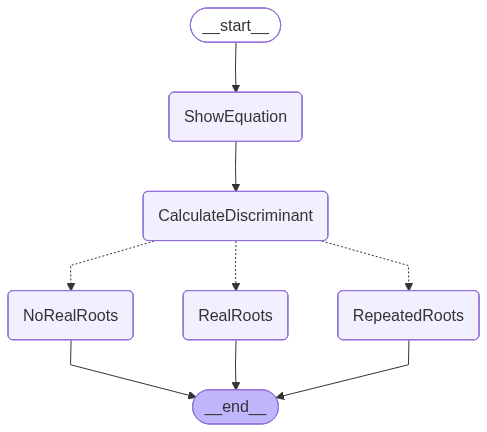

In [10]:
workflow

In [11]:
initial_state = {'a': 4, 'b': -5, 'c': -4}
final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 4, 'b': -5, 'c': -4, 'equation': ' (4) (x^2) + (-5) (x) + (-4) ', 'discriminant': 89, 'result': 'The roots are 1.8042476415070754 and -0.5542476415070754'}
